# Prototipo de Visualización y Comparación de Resultados para la Predicción de Remesas Familiares hacia El Salvador (1991–2025)

**Maestría en Análisis y Visualización de Datos Masivos** - **Universidad Internacional de La Rioja (UNIR)**

---

**Proyecto:**  
*Predicción del volumen mensual de remesas familiares hacia El Salvador mediante modelos de machine learning e identificación de factores macroeconómicos determinantes (1991–2025).*

**Período de análisis:** enero de 1991 – diciembre de 2025

**Equipo:** 1B

**Integrantes:**
- Kelly Mabel Vílchez González
- Herbert Fernando Ramírez Aguilar

---

## Propósito del prototipo

Este notebook implementa un prototipo ejecutable para la integración, visualización y comparación de los resultados obtenidos durante el desarrollo del proyecto.

El prototipo consolida las salidas generadas en las etapas previas de construcción del dataset, análisis exploratorio y modelado predictivo, permitiendo presentar de forma estructurada la evolución histórica de las remesas, el pipeline metodológico, las predicciones obtenidas y las métricas de evaluación de los modelos.

Los modelos considerados son:

1. Regresión Lineal Múltiple como modelo baseline
2. Random Forest
3. XGBoost
4. Long Short-Term Memory (LSTM)

Los resultados presentados corresponden a una división cronológica de los datos, utilizando el período enero de 1992 – diciembre de 2019 como conjunto de entrenamiento y el período enero de 2020 – diciembre de 2025 como conjunto de prueba.

---

## Alcance del prototipo

El notebook está diseñado para:

- Cargar y validar el dataset maestro utilizado en el estudio;
- Presentar la evolución histórica de las remesas familiares;
- Visualizar el pipeline metodológico completo del proyecto;
- Integrar los resultados generados durante la etapa de modelado;
- Presentar las predicciones frente a los valores reales;
- Consolidar métricas homogéneas de evaluación;
- Comparar el desempeño de los cuatro modelos;
- Generar tablas y visualizaciones para facilitar la interpretación de resultados.

> **Nota metodológica:** La construcción del dataset maestro, el análisis exploratorio y el entrenamiento detallado de los modelos se desarrollan en los notebooks correspondientes a cada etapa del proyecto. El presente prototipo integra y presenta los resultados derivados de dichas fases para su análisis comparativo.

In [2]:
# =====================================================================================
# 1. IMPORTACIONES Y CONFIGURACIÓN GENERAL
# =====================================================================================
# Este notebook implementa un prototipo ejecutable para la presentación,
# integración y comparación de los resultados obtenidos durante el flujo
# predictivo desarrollado en el proyecto.
#
# El prototipo parte del dataset maestro previamente construido y de las
# salidas generadas durante la etapa de modelado.
#
# Requiere como entrada principal:
#   - data/Dataset_Maestro_Final.csv
#
# Utiliza como directorio de resultados:
#   - outputs_modelado/
#
# El entrenamiento detallado de los modelos se desarrolla en:
#   - notebooks/03_Modelado_Remesas_ElSalvador.ipynb
#
# Estructura del proyecto:
#
#   raíz/
#   ├── data/
#   ├── notebooks/
#   ├── outputs_eda/
#   └── outputs_modelado/
# =====================================================================================


# -------------------------------------------------------------------------------------
# MANIPULACIÓN Y CÁLCULO NUMÉRICO
# -------------------------------------------------------------------------------------

import pandas as pd
import numpy as np


# -------------------------------------------------------------------------------------
# SISTEMA DE ARCHIVOS
# -------------------------------------------------------------------------------------

from pathlib import Path


# -------------------------------------------------------------------------------------
# VISUALIZACIÓN
# -------------------------------------------------------------------------------------

import matplotlib.pyplot as plt
import seaborn as sns


# =====================================================================================
# CONFIGURACIÓN VISUAL
# =====================================================================================

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

sns.set_style("whitegrid")


# =====================================================================================
# COLORES POR MODELO
# =====================================================================================

COLORES = {
    'Regresión Lineal': '#e84545',
    'Random Forest': '#f0a500',
    'XGBoost': '#2ca02c',
    'LSTM': '#9467bd'
}

# Se utiliza una codificación visual consistente para facilitar
# la identificación de cada modelo en los gráficos comparativos.


# =====================================================================================
# RUTAS DEL PROYECTO
# =====================================================================================
# Detecta automáticamente la raíz del proyecto.
# Funciona tanto si el notebook se ejecuta desde la raíz
# como desde la carpeta notebooks/.
# =====================================================================================

CURRENT_DIR = Path.cwd()

if (CURRENT_DIR / 'data').exists():
    PROJECT_ROOT = CURRENT_DIR
elif (CURRENT_DIR.parent / 'data').exists():
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    raise FileNotFoundError(
        "No se encontró la carpeta 'data'. "
        "Ejecute el notebook desde la raíz del proyecto "
        "o desde la carpeta 'notebooks'."
    )

DATA_DIR = PROJECT_ROOT / 'data'
OUTPUTS = PROJECT_ROOT / 'outputs_modelado'

DATA_PATH = DATA_DIR / 'Dataset_Maestro_Final.csv'


# =====================================================================================
# VERIFICACIÓN DE RECURSOS
# =====================================================================================

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "No se encontró el dataset maestro en la ruta esperada:\n"
        f"{DATA_PATH}"
    )

if not OUTPUTS.exists():
    raise FileNotFoundError(
        "No se encontró la carpeta de resultados del modelado:\n"
        f"{OUTPUTS}\n\n"
        "Ejecute previamente el notebook "
        "'03_Modelado_Remesas_ElSalvador.ipynb'."
    )


# =====================================================================================
# VERIFICACIÓN INICIAL
# =====================================================================================

print("=== CONFIGURACIÓN DEL PROTOTIPO ===")

print(
    f"\nDirectorio del proyecto:\n"
    f"{PROJECT_ROOT}"
)

print(
    f"\nDataset maestro:\n"
    f"{DATA_PATH}"
)

print(
    f"\nCarpeta de resultados:\n"
    f"{OUTPUTS}"
)

print(
    "\nConfiguración cargada correctamente."
)

=== CONFIGURACIÓN DEL PROTOTIPO ===

Directorio del proyecto:
C:\Users\kmabe\TFM

Dataset maestro:
C:\Users\kmabe\TFM\data\Dataset_Maestro_Final.csv

Carpeta de resultados:
C:\Users\kmabe\TFM\outputs_modelado

Configuración cargada correctamente.


---
## Sección 1 — Carga y validación del dataset maestro

El dataset maestro integra información procedente de cuatro fuentes institucionales y un componente de construcción propia: el Banco Central de Reserva de El Salvador (BCR), Federal Reserve Economic Data (FRED), el Banco Mundial, el Department of Homeland Security (DHS) de Estados Unidos y variables derivadas de la serie temporal y de criterios metodológicos definidos en el estudio.

La base cubre el período comprendido entre enero de 1991 y diciembre de 2025, con frecuencia mensual.

Las variables de construcción propia incluyen rezagos temporales de las remesas y variables dummy utilizadas para representar períodos específicos definidos metodológicamente.

En esta sección se carga y valida el dataset maestro utilizado en el proyecto. Asimismo, se replica el tratamiento definido para la variable `Deportaciones_Total` y se verifican la cobertura temporal, la estructura de los datos y la presencia de valores faltantes.

In [4]:
# ============================================================
# 2. CARGA Y VALIDACIÓN DEL DATASET MAESTRO
# ============================================================
# Esta celda:
#   1. Verifica la existencia del archivo de entrada.
#   2. Carga el dataset maestro.
#   3. Ordena cronológicamente las observaciones.
#   4. Verifica las columnas mínimas requeridas.
#   5. Replica el tratamiento de Deportaciones_Total según
#      la metodología definida en el estudio.
#   6. Resume la estructura y los valores faltantes.
# ============================================================


# ----------------------------------------------------------
# PASO 1: Verificar archivo de entrada
# ----------------------------------------------------------

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "No se encontró el dataset maestro en la ruta esperada:\n"
        f"{DATA_PATH}"
    )


# ----------------------------------------------------------
# PASO 2: Cargar dataset maestro
# ----------------------------------------------------------

df = pd.read_csv(
    DATA_PATH,
    parse_dates=['Fecha'],
    index_col='Fecha'
)

# Garantizar el orden cronológico de las observaciones
df = df.sort_index()


# ----------------------------------------------------------
# PASO 3: Verificar columnas mínimas requeridas
# ----------------------------------------------------------

COLUMNAS_REQUERIDAS = [
    'Remesas_Millones_USD',
    'Deportaciones_Total',
    'Remesas_Lag12'
]

columnas_faltantes = [
    columna
    for columna in COLUMNAS_REQUERIDAS
    if columna not in df.columns
]

if columnas_faltantes:
    raise ValueError(
        "El dataset no contiene las columnas requeridas:\n"
        f"{columnas_faltantes}"
    )


# ----------------------------------------------------------
# PASO 4: Replicar tratamiento de Deportaciones_Total
# ----------------------------------------------------------
# Se aplica la lógica metodológica utilizada en el estudio:
#
#   - 1991: promedio mensual observado en 1992.
#   - 2023-2025: promedio mensual del período 2020-2022.
#
# Este tratamiento permite presentar el dataset bajo los mismos
# criterios definidos en las etapas previas del proyecto.
# ----------------------------------------------------------

anio_temporal = df.index.year


# 1991 → promedio mensual de 1992
valor_1992 = df.loc[
    anio_temporal == 1992,
    'Deportaciones_Total'
].mean()

df.loc[
    anio_temporal == 1991,
    'Deportaciones_Total'
] = valor_1992


# 2023-2025 → promedio mensual de 2020-2022
media_reciente = df.loc[
    np.isin(
        anio_temporal,
        [2020, 2021, 2022]
    ),
    'Deportaciones_Total'
].mean()

df.loc[
    np.isin(
        anio_temporal,
        [2023, 2024, 2025]
    ),
    'Deportaciones_Total'
] = media_reciente


# ----------------------------------------------------------
# PASO 5: Mostrar resumen del dataset
# ----------------------------------------------------------

print("=== DATASET MAESTRO ===")

print(
    f"\nPeríodo  : "
    f"{df.index.min().strftime('%B %Y')} → "
    f"{df.index.max().strftime('%B %Y')}"
)

print(
    f"Filas    : "
    f"{df.shape[0]} observaciones mensuales"
)

print(
    f"Columnas : "
    f"{df.shape[1]} variables"
)


# ----------------------------------------------------------
# PASO 6: Resumen de la variable objetivo
# ----------------------------------------------------------

print(
    "\nVariable objetivo — Remesas_Millones_USD:"
)

print(
    f"  Mínimo : "
    f"{df['Remesas_Millones_USD'].min():.1f} millones USD"
)

print(
    f"  Máximo : "
    f"{df['Remesas_Millones_USD'].max():.1f} millones USD"
)

print(
    f"  Media  : "
    f"{df['Remesas_Millones_USD'].mean():.1f} millones USD"
)


# ----------------------------------------------------------
# PASO 7: Verificar valores faltantes
# ----------------------------------------------------------

nulos = df.isnull().sum()
nulos_con_valor = nulos[nulos > 0]

print(
    "\nFaltantes por variable:"
)

if nulos_con_valor.empty:
    print(
        "  No se detectaron valores faltantes."
    )
else:
    print(
        nulos_con_valor
    )

print(
    "\nNota: los valores faltantes observados en las variables "
    "de rezago son estructurales y corresponden a los primeros "
    "meses de la serie, donde no existe historia previa suficiente "
    "para calcular cada rezago temporal."
)

=== DATASET MAESTRO ===

Período  : January 1991 → December 2025
Filas    : 420 observaciones mensuales
Columnas : 15 variables

Variable objetivo — Remesas_Millones_USD:
  Mínimo : 53.1 millones USD
  Máximo : 961.1 millones USD
  Media  : 307.3 millones USD

Faltantes por variable:
Remesas_Lag1      1
Remesas_Lag2      2
Remesas_Lag3      3
Remesas_Lag12    12
dtype: int64

Nota: los valores faltantes observados en las variables de rezago son estructurales y corresponden a los primeros meses de la serie, donde no existe historia previa suficiente para calcular cada rezago temporal.


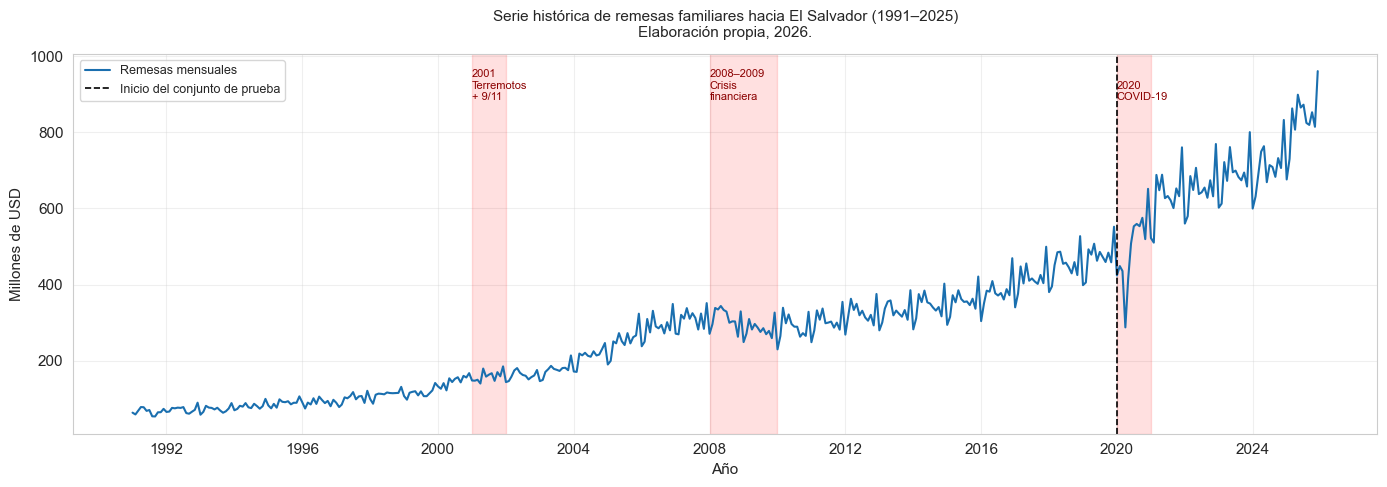

Figura guardada correctamente:
C:\Users\kmabe\TFM\outputs_modelado\prototipo_serie_historica.png


In [5]:
# ============================================================
# 3. VISUALIZACIÓN DE LA SERIE HISTÓRICA DE REMESAS
# ============================================================
# Esta celda representa la evolución mensual de las remesas
# familiares hacia El Salvador durante el período 1991-2025.
#
# También señala:
#   - los períodos definidos metodológicamente en el estudio para la variable Dummy_Crisis;
#   - el inicio del conjunto de prueba en enero de 2020.
#
# Los eventos mostrados corresponden a la contextualización
# temporal documentada en la metodología del proyecto.
# ============================================================


# ----------------------------------------------------------
# PASO 1: Crear figura
# ----------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(14, 5)
)


# ----------------------------------------------------------
# PASO 2: Graficar serie histórica
# ----------------------------------------------------------

ax.plot(
    df.index,
    df['Remesas_Millones_USD'],
    color='#1a6faf',
    linewidth=1.5,
    label='Remesas mensuales'
)


# ----------------------------------------------------------
# PASO 3: Señalar períodos de crisis
# ----------------------------------------------------------
# Estos intervalos corresponden a los períodos definidos
# metodológicamente en el estudio para Dummy_Crisis.

periodos_crisis = [
    (
        '2001-01-01',
        '2001-12-31',
        '2001\nTerremotos\n+ 9/11'
    ),
    (
        '2008-01-01',
        '2009-12-31',
        '2008–2009\nCrisis\nfinanciera'
    ),
    (
        '2020-01-01',
        '2020-12-31',
        '2020\nCOVID-19'
    )
]

max_remesas = df['Remesas_Millones_USD'].max()

for inicio, fin, etiqueta in periodos_crisis:

    inicio = pd.Timestamp(inicio)
    fin = pd.Timestamp(fin)

    ax.axvspan(
        inicio,
        fin,
        alpha=0.12,
        color='red'
    )

    ax.text(
        inicio,
        max_remesas * 0.92,
        etiqueta,
        fontsize=8,
        color='darkred',
        ha='left'
    )


# ----------------------------------------------------------
# PASO 4: Señalar inicio del conjunto de prueba
# ----------------------------------------------------------

ax.axvline(
    pd.Timestamp('2020-01-01'),
    color='black',
    linestyle='--',
    linewidth=1.2,
    label='Inicio del conjunto de prueba'
)


# ----------------------------------------------------------
# PASO 5: Formato final
# ----------------------------------------------------------

ax.set_title(
    'Serie histórica de remesas familiares hacia '
    'El Salvador (1991–2025)\n'
    'Elaboración propia, 2026.',
    fontsize=11,
    pad=12
)

ax.set_xlabel('Año')
ax.set_ylabel('Millones de USD')

ax.legend(
    fontsize=9
)

plt.tight_layout()


# ----------------------------------------------------------
# PASO 6: Guardar figura
# ----------------------------------------------------------

RUTA_FIGURA_SERIE = (
    OUTPUTS / 'prototipo_serie_historica.png'
)

plt.savefig(
    RUTA_FIGURA_SERIE,
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print("Figura guardada correctamente:")
print(RUTA_FIGURA_SERIE)

---
### Patrón estacional mensual de las remesas

Como complemento a la evolución histórica de la serie, se presenta el comportamiento de las remesas según el mes del año. Esta visualización resume uno de los hallazgos relevantes del análisis exploratorio desarrollado previamente y permite observar la presencia de variaciones estacionales recurrentes.

La identificación de este patrón aporta contexto para la incorporación de rezagos temporales, particularmente `Remesas_Lag12`, y para el uso de una ventana de 12 meses en el modelo LSTM. El análisis exploratorio completo se encuentra documentado en el notebook `02_EDA_Remesas_ElSalvador.ipynb`.

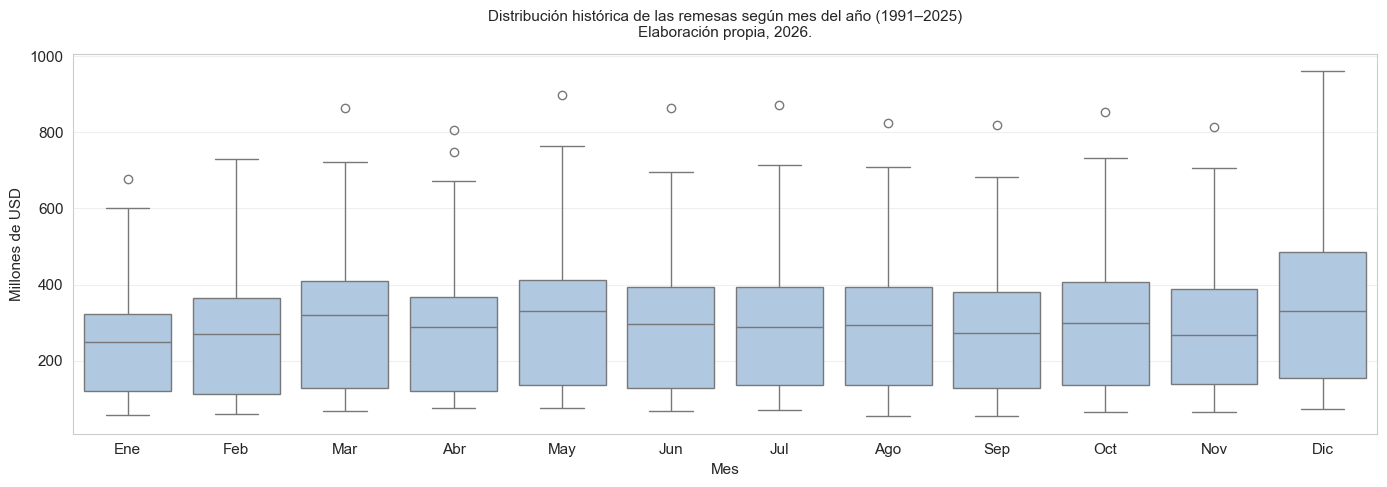

Figura de estacionalidad mensual guardada correctamente:
C:\Users\kmabe\TFM\outputs_modelado\prototipo_estacionalidad_mensual.png


In [7]:
# ============================================================
# 4. VISUALIZACIÓN DEL PATRÓN ESTACIONAL MENSUAL
# ============================================================
# Esta celda resume la distribución histórica de las remesas
# según el mes del año.
#
# Su propósito es recuperar, de forma sintética, uno de los
# hallazgos relevantes del análisis exploratorio desarrollado
# en el notebook 02_EDA_Remesas_ElSalvador.ipynb.
#
# La visualización permite observar diferencias recurrentes
# entre meses y aporta contexto para:
#   - la incorporación de Remesas_Lag12;
#   - el uso de una ventana temporal de 12 meses en el LSTM.
#
# Este gráfico tiene un propósito descriptivo y no sustituye
# el análisis exploratorio completo del proyecto.
# ============================================================


# ----------------------------------------------------------
# PASO 1: Preparar datos para la visualización
# ----------------------------------------------------------

df_estacionalidad = df[
    ['Remesas_Millones_USD']
].copy()

df_estacionalidad['Mes_Numero'] = (
    df_estacionalidad.index.month
)

nombres_meses = {
    1: 'Ene',
    2: 'Feb',
    3: 'Mar',
    4: 'Abr',
    5: 'May',
    6: 'Jun',
    7: 'Jul',
    8: 'Ago',
    9: 'Sep',
    10: 'Oct',
    11: 'Nov',
    12: 'Dic'
}

df_estacionalidad['Mes'] = (
    df_estacionalidad['Mes_Numero']
    .map(nombres_meses)
)

orden_meses = [
    'Ene',
    'Feb',
    'Mar',
    'Abr',
    'May',
    'Jun',
    'Jul',
    'Ago',
    'Sep',
    'Oct',
    'Nov',
    'Dic'
]


# ----------------------------------------------------------
# PASO 2: Crear figura
# ----------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(14, 5)
)


# ----------------------------------------------------------
# PASO 3: Graficar distribución mensual
# ----------------------------------------------------------

sns.boxplot(
    data=df_estacionalidad,
    x='Mes',
    y='Remesas_Millones_USD',
    order=orden_meses,
    color='#a8c8e8',
    ax=ax
)


# ----------------------------------------------------------
# PASO 4: Formato final
# ----------------------------------------------------------

ax.set_title(
    'Distribución histórica de las remesas según mes del año '
    '(1991–2025)\n'
    'Elaboración propia, 2026.',
    fontsize=11,
    pad=12
)

ax.set_xlabel(
    'Mes'
)

ax.set_ylabel(
    'Millones de USD'
)

plt.tight_layout()


# ----------------------------------------------------------
# PASO 5: Guardar figura
# ----------------------------------------------------------

RUTA_FIGURA_ESTACIONALIDAD = (
    OUTPUTS / 'prototipo_estacionalidad_mensual.png'
)

plt.savefig(
    RUTA_FIGURA_ESTACIONALIDAD,
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print(
    "Figura de estacionalidad mensual guardada correctamente:"
)

print(
    RUTA_FIGURA_ESTACIONALIDAD
)

---
## Sección 2 — Pipeline de procesamiento y modelado

La metodología general del proyecto se estructura en diez etapas secuenciales, desde la extracción e integración de las fuentes originales hasta el entrenamiento, la evaluación y la comparación de los modelos predictivos.

El presente prototipo se sitúa en la etapa final del flujo metodológico y tiene como propósito integrar, visualizar y comparar los resultados obtenidos en las fases previas del proyecto. La construcción del dataset maestro, el análisis exploratorio y el entrenamiento detallado de los modelos se desarrollan en los notebooks correspondientes a cada etapa.

El siguiente diagrama resume el flujo metodológico completo documentado en el proyecto y permite ubicar el alcance específico del prototipo dentro de dicho proceso.

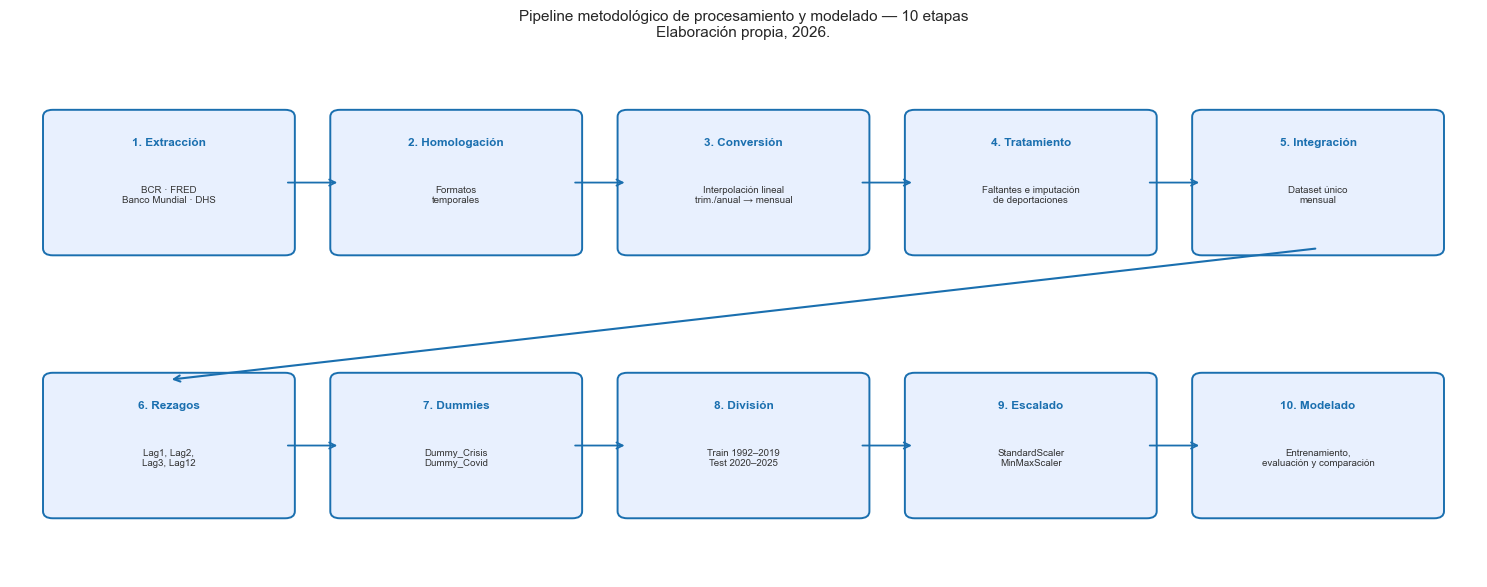

Diagrama del pipeline guardado correctamente:
C:\Users\kmabe\TFM\outputs_modelado\prototipo_pipeline.png


In [9]:
# ============================================================================================
# 5. DIAGRAMA DEL PIPELINE DE PROCESAMIENTO Y MODELADO
# ============================================================================================
# Representa las 10 etapas del flujo metodológico completo documentado
# en la Sección 8.2 del proyecto.
#
# El diagrama contextualiza las etapas desarrolladas en los distintos
# notebooks del proyecto, desde la extracción de las fuentes originales
# hasta el entrenamiento, la evaluación y la comparación de modelos.
#
# El presente prototipo se orienta a la integración, visualización
# y comparación de los resultados obtenidos en dichas etapas.
#
# Las etapas se distribuyen en dos filas para mantener la legibilidad.
# ============================================================================================

from matplotlib.patches import FancyBboxPatch


# --------------------------------------------------------------------------------------------
# PASO 1: Crear figura
# --------------------------------------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(15, 6)
)

ax.set_xlim(0, 12)
ax.set_ylim(0, 6)
ax.axis('off')


# --------------------------------------------------------------------------------------------
# PASO 2: Definir las etapas del pipeline
# --------------------------------------------------------------------------------------------

etapas_fila1 = [
    (
        "1",
        "Extracción",
        "BCR · FRED\nBanco Mundial · DHS"
    ),
    (
        "2",
        "Homologación",
        "Formatos\ntemporales"
    ),
    (
        "3",
        "Conversión",
        "Interpolación lineal\ntrim./anual → mensual"
    ),
    (
        "4",
        "Tratamiento",
        "Faltantes e imputación\nde deportaciones"
    ),
    (
        "5",
        "Integración",
        "Dataset único\nmensual"
    )
]

etapas_fila2 = [
    (
        "6",
        "Rezagos",
        "Lag1, Lag2,\nLag3, Lag12"
    ),
    (
        "7",
        "Dummies",
        "Dummy_Crisis\nDummy_Covid"
    ),
    (
        "8",
        "División",
        "Train 1992–2019\nTest 2020–2025"
    ),
    (
        "9",
        "Escalado",
        "StandardScaler\nMinMaxScaler"
    ),
    (
        "10",
        "Modelado",
        "Entrenamiento,\nevaluación y comparación"
    )
]


# --------------------------------------------------------------------------------------------
# PASO 3: Definir función para dibujar cada fila
# --------------------------------------------------------------------------------------------

def dibujar_fila(etapas, y_centro, ax):

    n_etapas = len(etapas)

    posiciones_x = np.linspace(
        1.3,
        10.7,
        n_etapas
    )

    for (
        numero,
        titulo,
        detalle
    ), x in zip(
        etapas,
        posiciones_x
    ):

        caja = FancyBboxPatch(
            (
                x - 0.95,
                y_centro - 0.75
            ),
            1.9,
            1.5,
            boxstyle="round,pad=0.08",
            facecolor='#e8f0fe',
            edgecolor='#1a6faf',
            linewidth=1.4
        )

        ax.add_patch(caja)

        ax.text(
            x,
            y_centro + 0.45,
            f"{numero}. {titulo}",
            ha='center',
            va='center',
            fontsize=8.5,
            fontweight='bold',
            color='#1a6faf'
        )

        ax.text(
            x,
            y_centro - 0.15,
            detalle,
            ha='center',
            va='center',
            fontsize=7,
            color='#333333'
        )


    # Flechas entre cajas de la misma fila
    for i in range(
        n_etapas - 1
    ):

        ax.annotate(
            '',
            xy=(
                posiciones_x[i + 1] - 0.95,
                y_centro
            ),
            xytext=(
                posiciones_x[i] + 0.95,
                y_centro
            ),
            arrowprops=dict(
                arrowstyle='->',
                color='#1a6faf',
                lw=1.3
            )
        )

    return posiciones_x


# --------------------------------------------------------------------------------------------
# PASO 4: Dibujar las dos filas
# --------------------------------------------------------------------------------------------

xs_fila1 = dibujar_fila(
    etapas_fila1,
    4.5,
    ax
)

xs_fila2 = dibujar_fila(
    etapas_fila2,
    1.5,
    ax
)


# --------------------------------------------------------------------------------------------
# PASO 5: Conectar etapa 5 con etapa 6
# --------------------------------------------------------------------------------------------

ax.annotate(
    '',
    xy=(
        xs_fila2[0],
        2.25
    ),
    xytext=(
        xs_fila1[-1],
        3.75
    ),
    arrowprops=dict(
        arrowstyle='->',
        color='#1a6faf',
        lw=1.5,
        connectionstyle="arc3,rad=0.0"
    )
)


# --------------------------------------------------------------------------------------------
# PASO 6: Formato final
# --------------------------------------------------------------------------------------------

ax.set_title(
    'Pipeline metodológico de procesamiento y modelado — 10 etapas\n'
    'Elaboración propia, 2026.',
    fontsize=11,
    pad=10
)

plt.tight_layout()


# --------------------------------------------------------------------------------------------
# PASO 7: Guardar figura
# --------------------------------------------------------------------------------------------

RUTA_FIGURA_PIPELINE = (
    OUTPUTS / 'prototipo_pipeline.png'
)

plt.savefig(
    RUTA_FIGURA_PIPELINE,
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print(
    "Diagrama del pipeline guardado correctamente:"
)

print(
    RUTA_FIGURA_PIPELINE
)

---
## Sección 3 — Resultados de los modelos predictivos

Esta sección integra los resultados obtenidos durante la etapa de modelado desarrollada previamente en el notebook `03_Modelado_Remesas_ElSalvador.ipynb`.

Se presentan las predicciones generadas por los cuatro modelos evaluados —Regresión Lineal Múltiple, Random Forest, XGBoost y LSTM— junto con las métricas RMSE, MAE, R² y MAPE utilizadas para comparar su desempeño.

Los resultados corresponden al esquema de evaluación cronológica definido en el estudio, con entrenamiento hasta diciembre de 2019 y evaluación sobre el período enero de 2020 – diciembre de 2025.

Las visualizaciones siguientes permiten contrastar las predicciones de cada modelo frente a los valores reales y analizar comparativamente su comportamiento durante el período de prueba.


Regresión Lineal
RMSE : 74.62 millones USD
MAE  : 56.09 millones USD
R²   : 0.6192
MAPE : 8.89%
Período de evaluación : 2020-01 a 2025-12
Observaciones          : 72



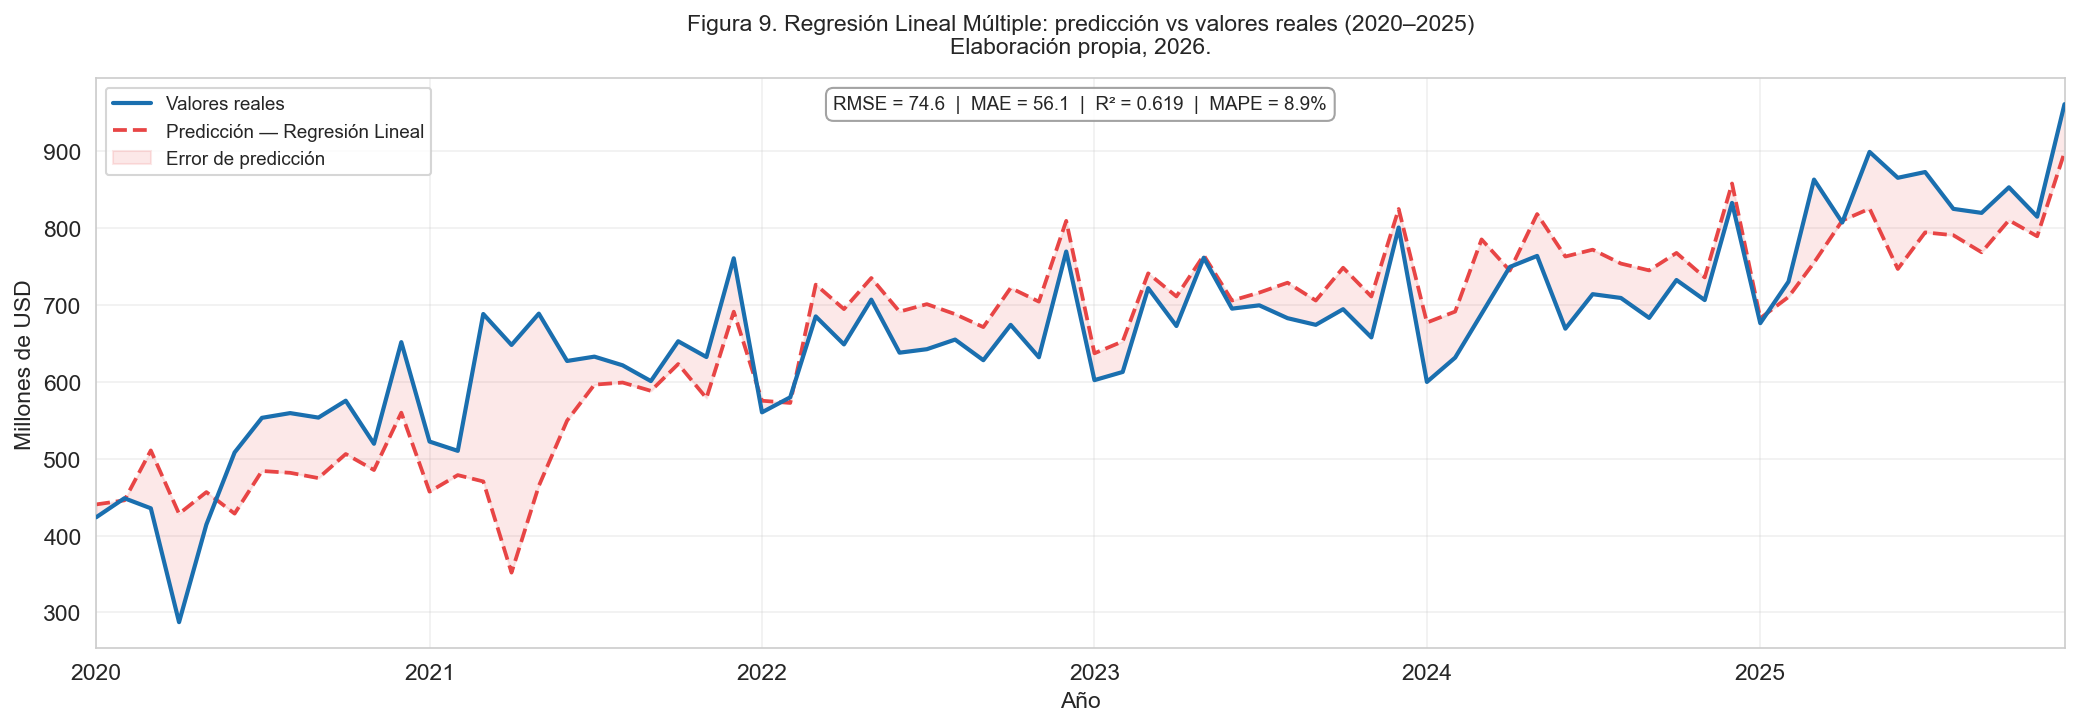


Random Forest
RMSE : 232.51 millones USD
MAE  : 208.15 millones USD
R²   : -2.6973
MAPE : 29.57%
Período de evaluación : 2020-01 a 2025-12
Observaciones          : 72



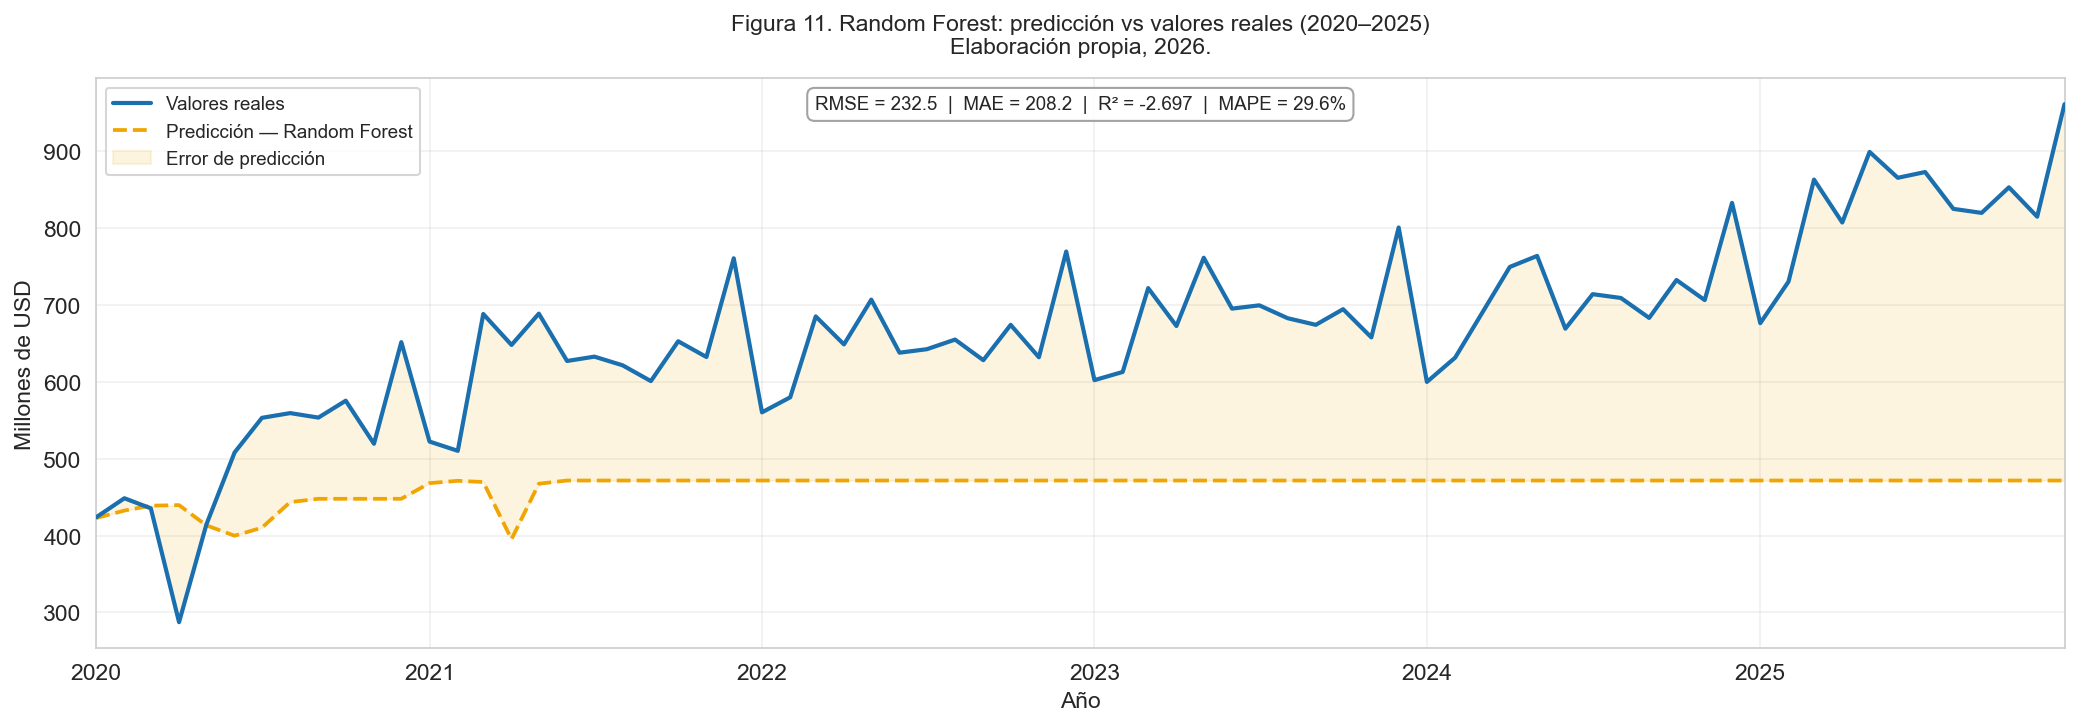


XGBoost
RMSE : 220.52 millones USD
MAE  : 196.79 millones USD
R²   : -2.3258
MAPE : 28.26%
Período de evaluación : 2020-01 a 2025-12
Observaciones          : 72



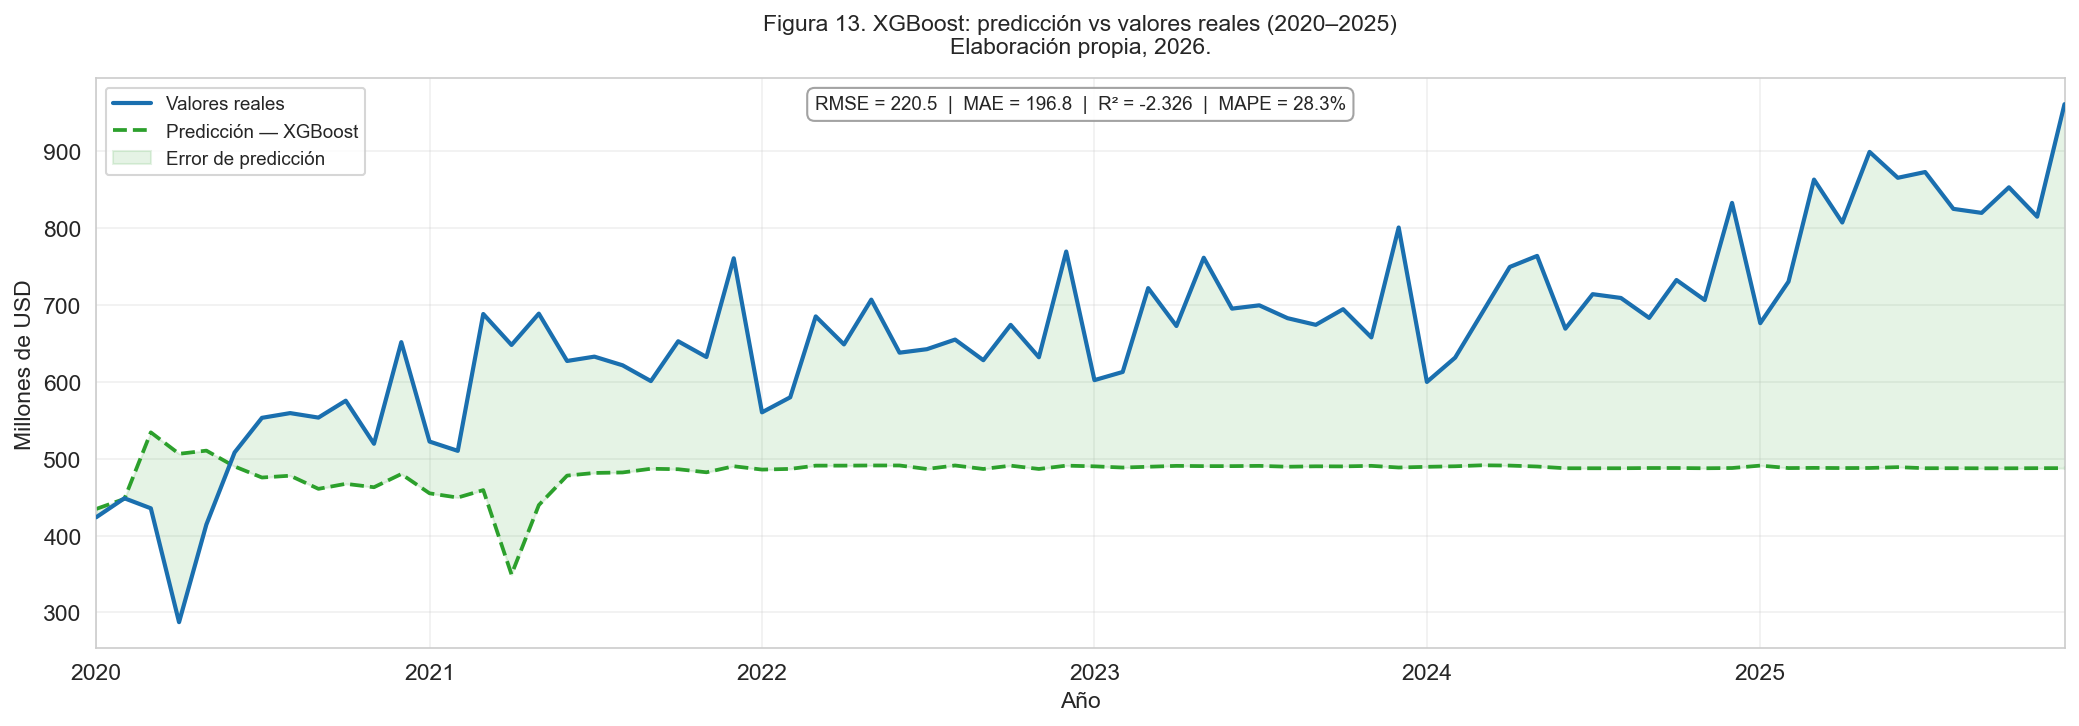


LSTM
RMSE : 192.81 millones USD
MAE  : 177.20 millones USD
R²   : -1.5425
MAPE : 26.18%
Período de evaluación : 2020-01 a 2025-12
Observaciones          : 72



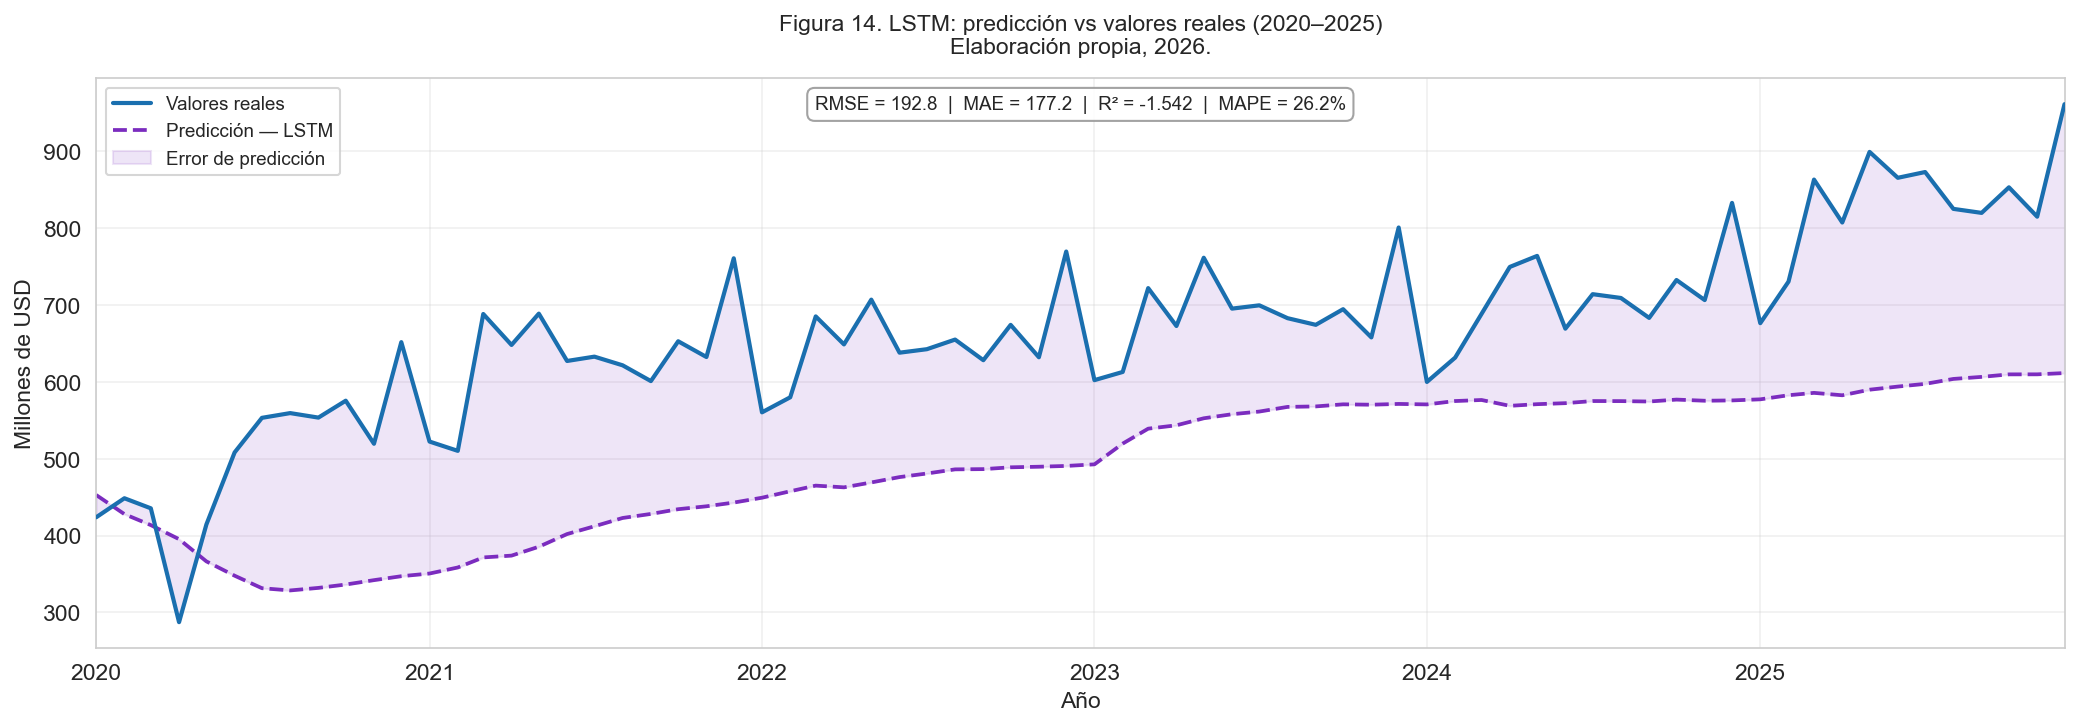

In [11]:
# ============================================================
# 6. FIGURAS DE PREDICCIÓN POR MODELO
# ============================================================
# Esta celda carga y presenta las figuras generadas previamente
# durante la etapa de modelado.
#
# Además, recupera dinámicamente las métricas de evaluación
# desde la tabla consolidada generada por el Notebook 3.
#
# Fuentes:
#   03_Modelado_Remesas_ElSalvador.ipynb
#   tabla_comparacion_modelos.csv
#
# No se recalculan métricas ni se reentrenan modelos.
# ============================================================

from IPython.display import display, Image as IPImage


# ----------------------------------------------------------
# PASO 1: Cargar métricas consolidadas
# ----------------------------------------------------------

ruta_metricas = (
    OUTPUTS / 'tabla_comparacion_modelos.csv'
)

if not ruta_metricas.exists():
    raise FileNotFoundError(
        "No se encontró la tabla de comparación de modelos:\n"
        f"{ruta_metricas}\n\n"
        "Ejecute previamente el notebook "
        "'03_Modelado_Remesas_ElSalvador.ipynb'."
    )

metricas_modelos = pd.read_csv(
    ruta_metricas
)


# ----------------------------------------------------------
# PASO 2: Definir figuras generadas por el modelado
# ----------------------------------------------------------

figuras = [
    (
        'Regresión Lineal',
        'figura9_prediccion_regresion_lineal.png'
    ),
    (
        'Random Forest',
        'figura11_prediccion_rf.png'
    ),
    (
        'XGBoost',
        'figura13_prediccion_xgb.png'
    ),
    (
        'LSTM',
        'figura14_prediccion_lstm.png'
    )
]


# ----------------------------------------------------------
# PASO 3: Verificar, mostrar métricas y presentar figuras
# ----------------------------------------------------------

for modelo, archivo in figuras:

    ruta = (
        OUTPUTS / archivo
    )

    print(
        f"\n{'=' * 60}"
    )

    print(
        f"{modelo}"
    )

    print(
        f"{'=' * 60}"
    )

    # Recuperar métricas del modelo
    fila_metricas = metricas_modelos[
        metricas_modelos['Modelo'] == modelo
    ]

    if not fila_metricas.empty:

        resultados = fila_metricas.iloc[0]

        print(
            f"RMSE : "
            f"{resultados['RMSE']:.2f} millones USD"
        )

        print(
            f"MAE  : "
            f"{resultados['MAE']:.2f} millones USD"
        )

        print(
            f"R²   : "
            f"{resultados['R²']:.4f}"
        )

        print(
            f"MAPE : "
            f"{resultados['MAPE']:.2f}%"
        )

        print(
            f"Período de evaluación : "
            f"{resultados['Período evaluación']}"
        )

        print(
            f"Observaciones          : "
            f"{int(resultados['Observaciones'])}"
        )

    else:

        print(
            "Métricas no encontradas para este modelo."
        )

    print()

    # Mostrar figura
    if ruta.exists():

        display(
            IPImage(
                filename=str(ruta),
                width=900
            )
        )

    else:

        print(
            "Figura no encontrada:"
        )

        print(
            ruta
        )

        print(
            "\nEjecute previamente el notebook "
            "'03_Modelado_Remesas_ElSalvador.ipynb'."
        )

=== IMPORTANCIA DE VARIABLES ===

Las figuras presentan la importancia relativa de las variables utilizadas por los modelos Random Forest y XGBoost durante la etapa de modelado.

Estas importancias describen la contribución de los predictores dentro de cada modelo y no implican relaciones causales.

Random Forest — Importancia de variables


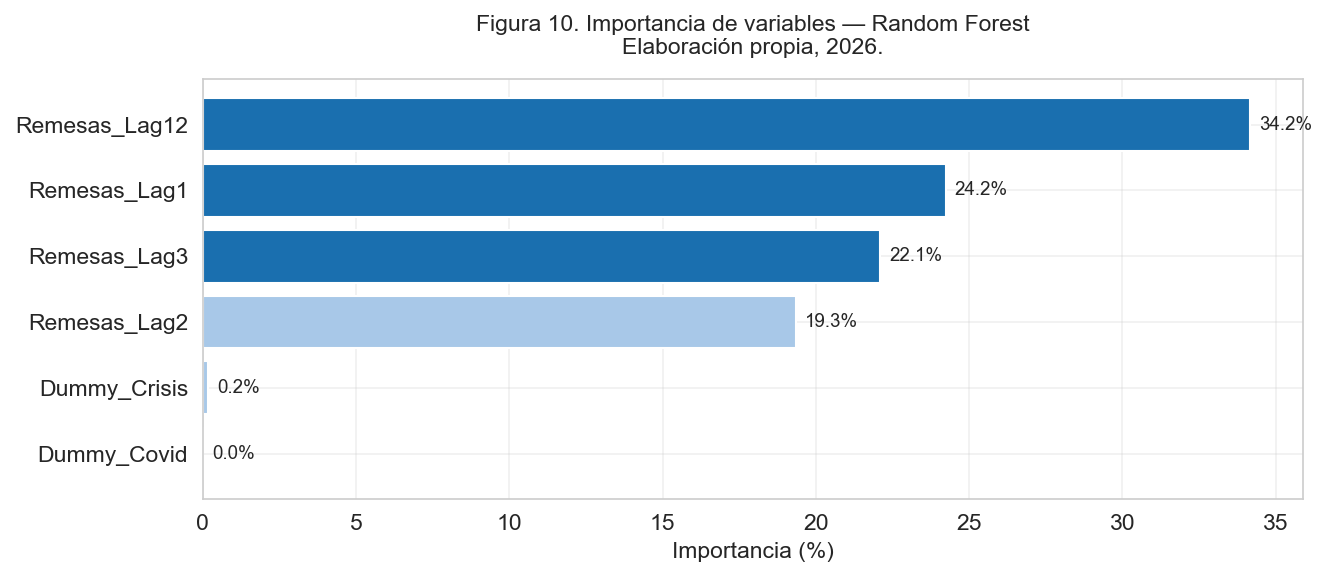


XGBoost — Importancia de variables


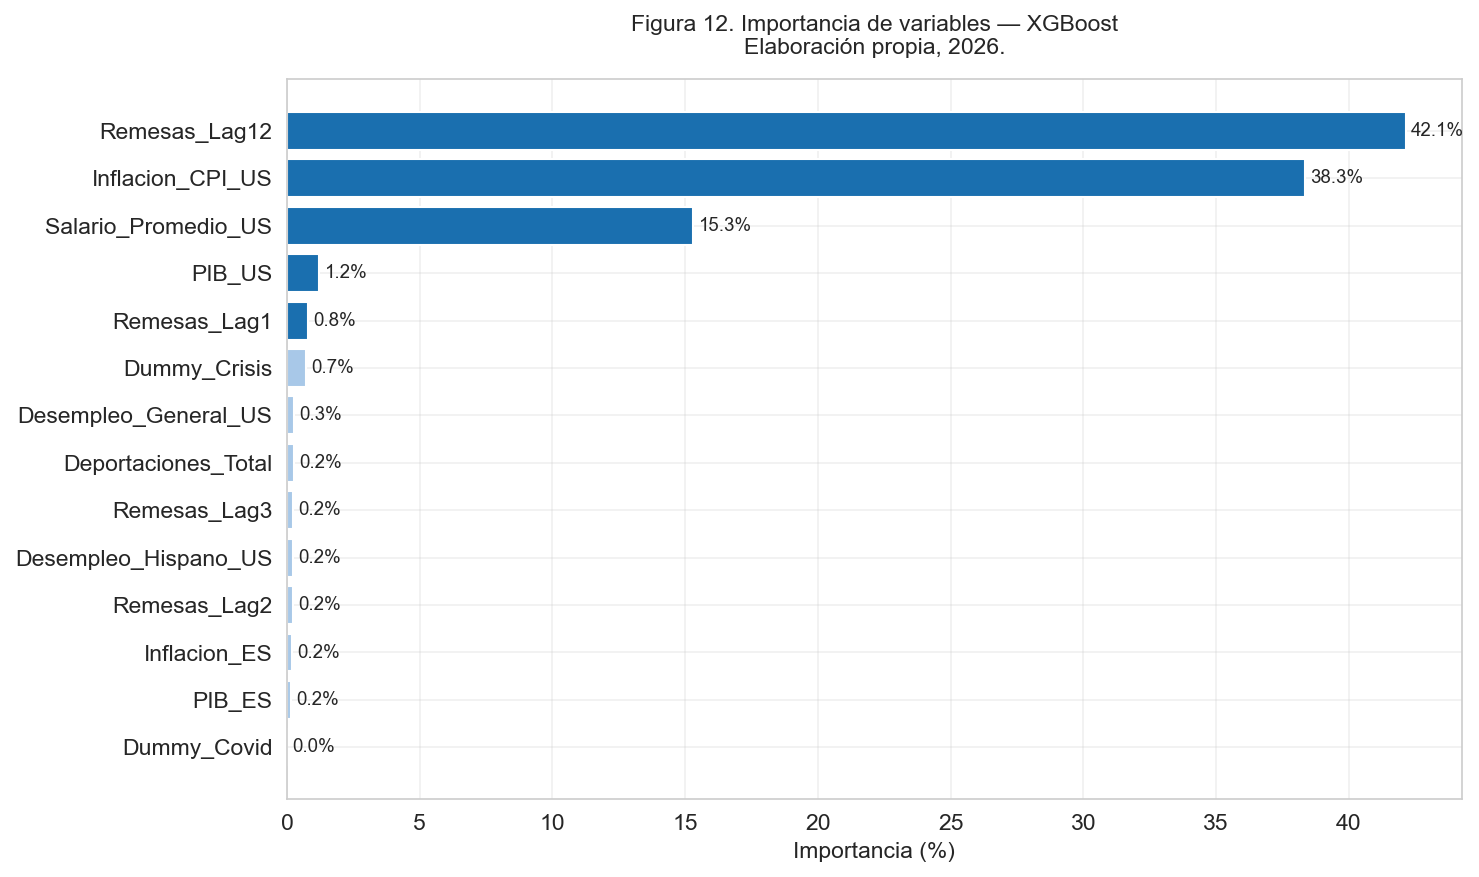

In [12]:
# ============================================================
# 7. IMPORTANCIA DE VARIABLES
# ============================================================
# Esta celda carga y presenta las figuras de importancia de
# variables generadas previamente durante la etapa de modelado.
#
# Fuentes:
#   03_Modelado_Remesas_ElSalvador.ipynb
#
# Las importancias corresponden a los modelos Random Forest
# y XGBoost ya entrenados. En esta celda no se recalculan
# importancias ni se reentrenan modelos.
# ============================================================

from IPython.display import display, Image as IPImage


# ----------------------------------------------------------
# PASO 1: Definir figuras de importancia
# ----------------------------------------------------------

figuras_imp = [
    (
        'Random Forest',
        'figura10_importancia_rf.png'
    ),
    (
        'XGBoost',
        'figura12_importancia_xgb.png'
    )
]


# ----------------------------------------------------------
# PASO 2: Verificar y mostrar cada figura
# ----------------------------------------------------------

print("=== IMPORTANCIA DE VARIABLES ===")

print(
    "\nLas figuras presentan la importancia relativa de las "
    "variables utilizadas por los modelos Random Forest y "
    "XGBoost durante la etapa de modelado."
)

print(
    "\nEstas importancias describen la contribución de los "
    "predictores dentro de cada modelo y no implican "
    "relaciones causales."
)


for modelo, archivo in figuras_imp:

    ruta = (
        OUTPUTS / archivo
    )

    print(
        f"\n{'=' * 60}"
    )

    print(
        f"{modelo} — Importancia de variables"
    )

    print(
        f"{'=' * 60}"
    )

    if ruta.exists():

        display(
            IPImage(
                filename=str(ruta),
                width=750
            )
        )

    else:

        print(
            "Figura no encontrada:"
        )

        print(
            ruta
        )

        print(
            "\nEjecute previamente el notebook "
            "'03_Modelado_Remesas_ElSalvador.ipynb'."
        )

---
## Sección 4 — Comparación final de modelos

En esta sección se integran y comparan los resultados obtenidos por los cuatro modelos predictivos evaluados: **Regresión Lineal Múltiple, Random Forest, XGBoost y LSTM**.

La comparación se realiza a partir de las métricas **RMSE, MAE, R² y MAPE**, calculadas previamente sobre el mismo período de prueba **2020–2025**, compuesto por **72 observaciones mensuales**. Los resultados se recuperan desde los archivos generados durante la etapa de modelado, sin reentrenar los modelos ni recalcular manualmente sus métricas.

El objetivo es identificar el modelo con mejor desempeño predictivo y analizar comparativamente las diferencias observadas entre enfoques lineales, modelos basados en árboles y redes neuronales recurrentes.

=== TABLA COMPARATIVA DE MÉTRICAS ===

Conjunto de prueba: enero 2020 – diciembre 2025 (72 observaciones)

          Modelo       RMSE        MAE        R²      MAPE Período evaluación  Observaciones
Regresión Lineal  74.621856  56.089110  0.619173  8.893162  2020-01 a 2025-12             72
   Random Forest 232.510319 208.154139 -2.697264 29.566331  2020-01 a 2025-12             72
         XGBoost 220.522006 196.787730 -2.325829 28.264589  2020-01 a 2025-12             72
            LSTM 192.811268 177.201985 -1.542499 26.182801  2020-01 a 2025-12             72

Mejor modelo por MAPE: Regresión Lineal (8.89%)


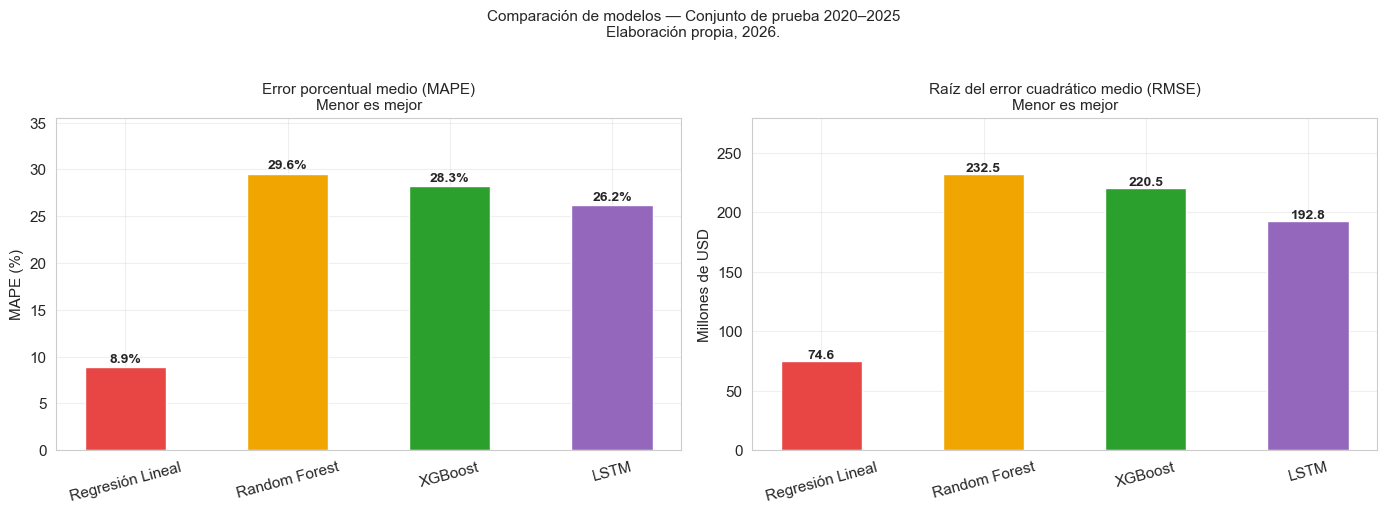


Gráfico comparativo guardado:
C:\Users\kmabe\TFM\outputs_modelado\prototipo_comparacion_modelos.png


In [14]:
# ============================================================
# COMPARACIÓN FINAL DE LOS 4 MODELOS
# ============================================================
# Esta celda integra los resultados obtenidos previamente
# durante la etapa de modelado.
#
# Fuente: tabla_comparacion_modelos.csv
#
# No se redefinen métricas manualmente, no se recalculan
# resultados y no se reentrenan modelos.
# ============================================================


# ----------------------------------------------------------
# PASO 1: Cargar tabla oficial de métricas
# ----------------------------------------------------------

ruta_metricas = (
    OUTPUTS / 'tabla_comparacion_modelos.csv'
)

if not ruta_metricas.exists():
    raise FileNotFoundError(
        "No se encontró la tabla de comparación de modelos:\n"
        f"{ruta_metricas}\n\n"
        "Ejecute previamente el notebook "
        "'03_Modelado_Remesas_ElSalvador.ipynb'."
    )

metricas = pd.read_csv(
    ruta_metricas
)


# ----------------------------------------------------------
# PASO 2: Mostrar tabla comparativa
# ----------------------------------------------------------

print("=== TABLA COMPARATIVA DE MÉTRICAS ===")

print(
    "\nConjunto de prueba: "
    "enero 2020 – diciembre 2025 "
    "(72 observaciones)\n"
)

print(
    metricas.to_string(
        index=False
    )
)


# ----------------------------------------------------------
# PASO 3: Identificar mejor modelo según MAPE
# ----------------------------------------------------------

indice_mejor = metricas['MAPE'].idxmin()

mejor_modelo = metricas.loc[
    indice_mejor,
    'Modelo'
]

mejor_mape = metricas.loc[
    indice_mejor,
    'MAPE'
]

print(
    f"\nMejor modelo por MAPE: "
    f"{mejor_modelo} "
    f"({mejor_mape:.2f}%)"
)


# ----------------------------------------------------------
# PASO 4: Preparar gráfico comparativo
# ----------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

modelos = metricas[
    'Modelo'
].tolist()

colores = [
    COLORES[m]
    for m in modelos
]


# ----------------------------------------------------------
# PANEL IZQUIERDO: MAPE
# ----------------------------------------------------------

axes[0].bar(
    modelos,
    metricas['MAPE'],
    color=colores,
    edgecolor='white',
    width=0.5
)

axes[0].set_title(
    'Error porcentual medio (MAPE)\n'
    'Menor es mejor',
    fontsize=11
)

axes[0].set_ylabel(
    'MAPE (%)'
)

axes[0].set_ylim(
    0,
    metricas['MAPE'].max() * 1.2
)

for i, v in enumerate(
    metricas['MAPE']
):
    axes[0].text(
        i,
        v + 0.5,
        f'{v:.1f}%',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )


# ----------------------------------------------------------
# PANEL DERECHO: RMSE
# ----------------------------------------------------------

axes[1].bar(
    modelos,
    metricas['RMSE'],
    color=colores,
    edgecolor='white',
    width=0.5
)

axes[1].set_title(
    'Raíz del error cuadrático medio (RMSE)\n'
    'Menor es mejor',
    fontsize=11
)

axes[1].set_ylabel(
    'Millones de USD'
)

axes[1].set_ylim(
    0,
    metricas['RMSE'].max() * 1.2
)

for i, v in enumerate(
    metricas['RMSE']
):
    axes[1].text(
        i,
        v + 2,
        f'{v:.1f}',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )


# ----------------------------------------------------------
# PASO 5: Formato final
# ----------------------------------------------------------

for ax in axes:
    ax.tick_params(
        axis='x',
        rotation=15
    )

fig.suptitle(
    'Comparación de modelos — Conjunto de prueba 2020–2025\n'
    'Elaboración propia, 2026.',
    fontsize=11,
    y=1.02
)

plt.tight_layout()


# ----------------------------------------------------------
# PASO 6: Guardar figura
# ----------------------------------------------------------

ruta_figura = (
    OUTPUTS / 'prototipo_comparacion_modelos.png'
)

plt.savefig(
    ruta_figura,
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print(
    "\nGráfico comparativo guardado:"
)

print(
    ruta_figura
)

---
## Sección 5 — Conclusiones sobre la efectividad predictiva

Una vez comparado el desempeño de los modelos, esta sección interpreta los resultados obtenidos y valora su efectividad para el problema planteado.

El análisis se centra en determinar qué enfoque ofrece predicciones más confiables, qué limitaciones presentan los modelos con mayor error y qué implicaciones tienen estos hallazgos para el desarrollo del prototipo predictivo de remesas hacia El Salvador.

In [16]:
# ============================================================
# CONCLUSIONES SOBRE EFECTIVIDAD
# ============================================================
# Esta celda sintetiza los resultados comparativos obtenidos
# durante la etapa de modelado.
#
# Las métricas se recuperan dinámicamente desde la tabla
# oficial generada por el Notebook 3.
#
# No se recalculan métricas ni se reentrenan modelos.
# ============================================================


# ----------------------------------------------------------
# PASO 1: Recuperar métricas oficiales por modelo
# ----------------------------------------------------------

resultados_por_modelo = (
    metricas
    .set_index('Modelo')
)

mape_lr = resultados_por_modelo.loc[
    'Regresión Lineal',
    'MAPE'
]

mape_rf = resultados_por_modelo.loc[
    'Random Forest',
    'MAPE'
]

mape_xgb = resultados_por_modelo.loc[
    'XGBoost',
    'MAPE'
]

mape_lstm = resultados_por_modelo.loc[
    'LSTM',
    'MAPE'
]

r2_lr = resultados_por_modelo.loc[
    'Regresión Lineal',
    'R²'
]


# ----------------------------------------------------------
# PASO 2: Construir conclusiones
# ----------------------------------------------------------

conclusiones = f"""
CONCLUSIONES SOBRE LA EFECTIVIDAD DE LOS MODELOS
=================================================

1. MEJOR DESEMPEÑO: REGRESIÓN LINEAL

   La Regresión Lineal presentó el mejor desempeño predictivo
   durante el período de prueba 2020-2025, con un MAPE de
   {mape_lr:.2f}% y un R² de {r2_lr:.4f}.

   El MAPE indica que, en promedio, el error absoluto de las
   predicciones representó aproximadamente el {mape_lr:.2f}%
   del valor real mensual de las remesas. Además, fue el único
   modelo evaluado que obtuvo un R² positivo.


2. DESEMPEÑO DURANTE EL PERÍODO 2020-2025

   El período de prueba presentó niveles de remesas superiores
   a los observados durante buena parte del conjunto de
   entrenamiento, lo que representó un desafío para la
   capacidad de generalización de los modelos.

   Las figuras de predicción muestran diferencias importantes
   en la capacidad de cada enfoque para seguir la trayectoria
   observada durante 2020-2025, especialmente ante el aumento
   sostenido de los valores mensuales.


3. COMPARACIÓN DE LOS MODELOS

   Los errores porcentuales obtenidos fueron:

   - Regresión Lineal : {mape_lr:.2f}%
   - Random Forest    : {mape_rf:.2f}%
   - XGBoost          : {mape_xgb:.2f}%
   - LSTM             : {mape_lstm:.2f}%

   Random Forest y XGBoost presentaron mayores dificultades
   para reproducir los niveles observados en el período de
   prueba. La LSTM también mostró un error superior al de la
   Regresión Lineal, aunque su desempeño fue mejor que el de
   los dos modelos basados en árboles.

   En este experimento, una mayor complejidad algorítmica no
   se tradujo automáticamente en una mayor precisión predictiva.


4. HALLAZGOS SOBRE LOS PREDICTORES

   El análisis exploratorio evidenció asociaciones elevadas
   entre las remesas y variables macroeconómicas de Estados
   Unidos, mientras que el análisis temporal mostró una fuerte
   dependencia de la serie respecto a sus valores históricos.

   En los modelos basados en árboles, las importancias de
   variables deben interpretarse de acuerdo con los predictores
   incluidos en cada modelo. Random Forest mostró una fuerte
   relevancia de los rezagos de la propia serie, mientras que
   XGBoost destacó tanto variables temporales como variables
   macroeconómicas.

   Estos resultados describen asociaciones y contribuciones
   predictivas dentro de los modelos evaluados, y no implican
   relaciones causales.


5. IMPLICACIÓN PARA EL PROTOTIPO

   A partir de los resultados obtenidos, la Regresión Lineal
   constituye el modelo de referencia con mejor desempeño para
   el prototipo desarrollado.

   Su menor error y su R² positivo muestran una mejor capacidad
   predictiva relativa frente a Random Forest, XGBoost y LSTM
   bajo la partición temporal y las condiciones evaluadas.

   Como trabajo futuro, el prototipo podría actualizarse
   periódicamente con nuevas observaciones para evaluar si el
   desempeño de los modelos cambia a medida que se incorpora
   información más reciente.
"""


# ----------------------------------------------------------
# PASO 3: Mostrar conclusiones
# ----------------------------------------------------------

print(conclusiones)


# ----------------------------------------------------------
# PASO 4: Guardar conclusiones
# ----------------------------------------------------------

ruta_conclusiones = (
    OUTPUTS / 'conclusiones_efectividad.txt'
)

with open(
    ruta_conclusiones,
    'w',
    encoding='utf-8'
) as f:

    f.write(
        conclusiones
    )


print(
    "\nConclusiones guardadas:"
)

print(
    ruta_conclusiones
)


CONCLUSIONES SOBRE LA EFECTIVIDAD DE LOS MODELOS

1. MEJOR DESEMPEÑO: REGRESIÓN LINEAL

   La Regresión Lineal presentó el mejor desempeño predictivo
   durante el período de prueba 2020-2025, con un MAPE de
   8.89% y un R² de 0.6192.

   El MAPE indica que, en promedio, el error absoluto de las
   predicciones representó aproximadamente el 8.89%
   del valor real mensual de las remesas. Además, fue el único
   modelo evaluado que obtuvo un R² positivo.


2. DESEMPEÑO DURANTE EL PERÍODO 2020-2025

   El período de prueba presentó niveles de remesas superiores
   a los observados durante buena parte del conjunto de
   entrenamiento, lo que representó un desafío para la
   capacidad de generalización de los modelos.

   Las figuras de predicción muestran diferencias importantes
   en la capacidad de cada enfoque para seguir la trayectoria
   observada durante 2020-2025, especialmente ante el aumento
   sostenido de los valores mensuales.


3. COMPARACIÓN DE LOS MODELOS

   Los errores 